### Normalizing Flow 

This notebook will experiment with multiple aspects of Normalizing Flow related stuffs like:

1. Generate half-moon distribution - NICE will be used to do it. 
2. Sample from a distribution knowing its pdf.
3. Recentering techique will be applied for sampling process  

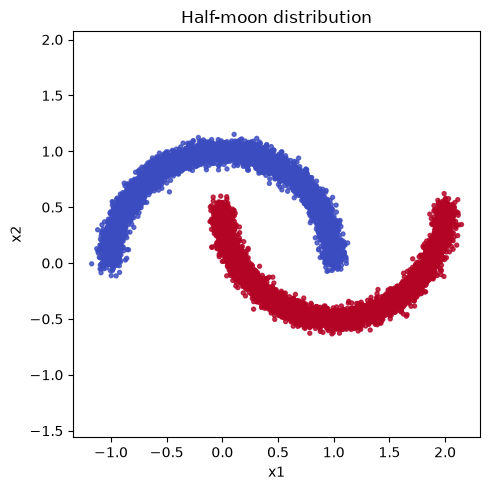

X shape: (10000, 2), y shape: (10000,)


In [2]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

n_samples = 10000
noise = 0.05
X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=8, cmap="coolwarm", alpha=0.8)
plt.title("Half-moon distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.tight_layout()
plt.show()

print(f"X shape: {X.shape}, y shape: {y.shape}")

### Train NICE on half-moon

Couplings have $\det=1$; learnable diagonal scaling contributes $\sum_i (\log s)_i$:

$$
\mathcal{L}(\theta)
= \mathbb{E}_{x \sim p_{\mathrm{data}}}\Big[\tfrac{1}{2}\|f_\theta(x)\|^2 - \sum_i (\log s)_i\Big]
$$

Train so latents look like $\mathcal{N}(0,I)$ while fitting volume via $\log s$.

In [10]:
import runpy
from pathlib import Path

import jax
import jax.numpy as jnp
import optax
from jax import random
from tqdm import trange

# project root on sys.path
_root = Path.cwd() if (Path.cwd() / "libs").is_dir() else Path.cwd().parent
runpy.run_path(str(_root / "setup_path.py"), run_name="__setup_path__")

from libs.nice_scratch import NICE

# --- data / model ---
X_train = jnp.asarray(X, dtype=jnp.float32)
model = NICE(layer_size=2, no_layers=4, hidden_sizes=(64, 64))

key = random.PRNGKey(0)
key, k_init = random.split(key)
variables = model.init(k_init, X_train[:8])
params = variables["params"]

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

def loss_fn(params, batch):
    z, log_det = model.apply({"params": params}, batch)
    # log_det = sum(log s); same for every sample in the batch
    return 0.5 * jnp.mean(jnp.sum(z**2, axis=-1)) - log_det

@jax.jit
def train_step(params, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, batch)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# --- 2000 epochs ---
n_epochs = 2000
batch_size = 128
losses = []

for epoch in trange(n_epochs, desc="NICE train"):
    key, k_perm = random.split(key)
    perm = random.permutation(k_perm, X_train.shape[0])
    X_shuf = X_train[perm]

    batch_losses = []
    # training with batch-SGD
    for start in range(0, X_train.shape[0], batch_size):
        batch = X_shuf[start : start + batch_size]
        params, opt_state, loss = train_step(params, opt_state, batch)
        batch_losses.append(loss)

    epoch_loss = float(jnp.mean(jnp.stack(batch_losses)))
    losses.append(epoch_loss)
    if epoch % 100 == 0:
        print("loss after {} epoch = {}".format(epoch, epoch_loss))

print(f"final loss: {losses[-1]:.4f} (start {losses[0]:.4f})")

NICE train:   0%| | 5/2000 [00:00<04:13,  7.88

loss after 0 epoch = 0.3391345143318176


NICE train:   5%| | 105/2000 [00:03<00:55, 33.

loss after 100 epoch = -1.1452122926712036


NICE train:  10%| | 205/2000 [00:06<00:53, 33.

...

loss after 1800 epoch = -1.2772067785263062


NICE train:  95%|▉| 1905/2000 [00:57<00:02, 34

loss after 1900 epoch = -1.198283314704895


NICE train: 100%|█| 2000/2000 [00:59<00:00, 33

final loss: -1.1994 (start 0.3391)


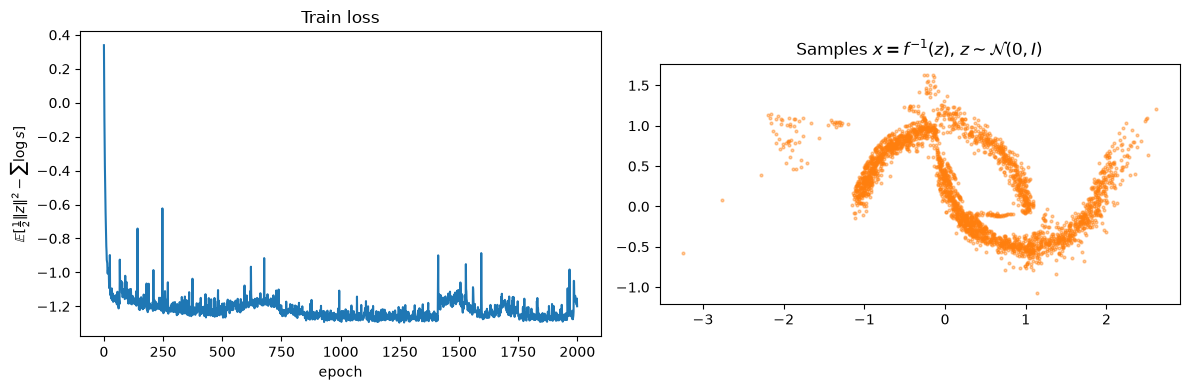

In [11]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title("Train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel(r"$\mathbb{E}[\frac{1}{2}\|z\|^2 - \sum \log s]$")

key, k_samp = random.split(key)
z_prior = random.normal(k_samp, (3000, 2))
x_gen, _ = model.apply({"params": params}, z_prior, reverse=True)
axes[1].scatter(np.asarray(x_gen[:, 0]), np.asarray(x_gen[:, 1]), s=4, alpha=0.4, c="tab:orange")
axes[1].set_title(r"Samples $x = f^{-1}(z)$, $z\sim\mathcal{N}(0,I)$")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()